# EXP-008 — Hierarchical LR + interaction(k2, GC-bin)

**Статус:** подготовлен, но ни одна code cell не выполнена.

EXP-007 становится новым champion. Здесь сохраняются все его main
effects и добавляются только 128 reference-coded взаимодействий между
strand-oriented динуклеотидом `[-1,0]` и GC201-bin.

Не используйте **Run All**. Выполняйте ячейки сверху вниз.


## Карта эксперимента

1. Воспроизвести exact `6-mer × GC201` counts EXP-007.
2. Проверить train-only support и enrichment `k2 × GC-bin`.
3. Собрать 4 379 main-effect и 128 interaction-столбцов.
4. Выполнить только 5 значений `C × 3 folds = 15 fits`.
5. Сравнить каждый fold с новым champion EXP-007.
6. Открыть validation только после paired CV gate.
7. Сохранить метрики, heatmaps взаимодействий и отчёт.


In [1]:
from pathlib import Path
import json
import os
import platform
import sys
import time

# This must happen before NumPy/SciPy/sklearn are imported. The
# environment used for EXP-007 can otherwise load incompatible Intel
# and LLVM OpenMP runtimes into one process.
_NUMERIC_STACK_ALREADY_LOADED = any(
    name == "numpy" or name.startswith("numpy.") for name in sys.modules
)
if (
    _NUMERIC_STACK_ALREADY_LOADED
    and os.environ.get("MKL_THREADING_LAYER", "").upper() != "SEQUENTIAL"
):
    raise RuntimeError(
        "Restart the kernel before EXP-008: the numeric stack was "
        "already loaded without MKL_THREADING_LAYER=SEQUENTIAL."
    )
os.environ["MKL_THREADING_LAYER"] = "SEQUENTIAL"
os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (candidate / "README.md").is_file()
    and (candidate / "src/ml_project").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project.epic_baseline import load_baseline_sequences
from ml_project.epic_data import ensure_prepared_split
from ml_project.epic_experiment import ExperimentSpec, build_run_record, save_run_record
from ml_project.epic_gc_interaction_logistic import (
    GCInteractionLogisticConfig,
    K2_LABELS,
    aggregate_gc_interaction_likelihood,
    cross_validate_gc_interaction_logistic,
    evaluate_gc_interaction_logistic,
    fit_gc_interaction_logistic,
    interaction_enrichment_table,
    interaction_feature_table,
    selected_cv_interaction_coefficients,
)
from ml_project.epic_gc_binned_logistic import GC_BIN_LABELS
from ml_project.epic_gc_logistic import (
    gc_count_diagnostics,
    kmer_counts_from_gc_counts,
    split_kmer_gc_counts,
)
from ml_project.epic_kmer import KmerLookupConfig, evaluate_kmer_lookup, fit_kmer_lookup
from ml_project.epic_kmer_logistic import (
    hierarchical_kmer_design,
    make_balanced_contig_folds,
    select_regularization,
    summarise_cv,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)

display(pd.Series({
    "python": platform.python_version(),
    "executable": sys.executable,
    "project_root": str(PROJECT_ROOT),
    "notebook_state": "prepared / unexecuted",
    "threadpoolctl_used_for_fit": False,
    "MKL_THREADING_LAYER": os.environ["MKL_THREADING_LAYER"],
    "OMP_NUM_THREADS": os.environ["OMP_NUM_THREADS"],
}, name="value").to_frame())


,value
python,3.12.14
executable,C:\ML_Progs\Runtimes\Miniforge3\envs\epic-eda\...
project_root,D:\Projects\EPIC\EPIC
notebook_state,prepared / unexecuted
threadpoolctl_used_for_fit,False
MKL_THREADING_LAYER,SEQUENTIAL
OMP_NUM_THREADS,2


## 1. Зафиксированный конфиг

Main effects полностью совпадают с EXP-007. Interaction использует
references `k2=TT` и `GC=[0.35,0.40)`, поэтому добавляется
`(17−1) × (9−1) = 128` столбцов без линейной зависимости от main effects.

Перед первой ячейкой перезапустите kernel, если в нём уже выполнялся
EXP-007. Setup фиксирует безопасный MKL backend **до** импорта NumPy;
это устраняет конфликт OpenMP, а не просто скрывает warning.

Grid сокращён до пяти значений вокруг устойчивого оптимума `0.0003`:
`0.0001, 0.0002, 0.0003, 0.0005, 0.001`.


In [2]:
RUN_NAME = "run_001"
EXPERIMENT_ID = "EXP-008"
NOTEBOOK_PATH = PROJECT_ROOT / "notebooks/experiments/EXP-008_k2_gc_interaction.ipynb"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts/experiments/EXP-008" / RUN_NAME
PLOT_DIR = ARTIFACT_DIR / "plots"

CONFIG = GCInteractionLogisticConfig()
LOOKUP_CONFIG = KmerLookupConfig(ks=CONFIG.ks, smoothing="one_expected_positive")
SPEC = ExperimentSpec(
    experiment_id=EXPERIMENT_ID,
    title="Hierarchical LR + interaction(k2[-1,0], GC201-bin)",
    hypothesis=(
        "The usefulness of the start-site dinucleotide depends on the "
        "regional GC promoter class beyond additive EXP-007 effects"
    ),
    changed_variable=(
        "EXP-007 + 128 reference-coded k2[-1,0] x GC201-bin interactions"
    ),
    success_criterion=(
        "Before validation: AP win over EXP-007 on all 3 identical CV folds; "
        "validation: relative AP gain >= 1%, Spearman not lower, "
        "AP wins on at least 2/3 validation contigs"
    ),
    seed=CONFIG.seed,
)
assert len(CONFIG.C_grid) * CONFIG.cv_folds == 15
assert not (ARTIFACT_DIR / "metadata.json").exists(), (
    f"Run already exists: {ARTIFACT_DIR}. Use another run name; do not overwrite."
)
display(pd.Series(CONFIG.to_dict(), name="value").to_frame())
display(interaction_feature_table(CONFIG))


,value
ks,"[2, 4, 6]"
window_start,-100
window_end,100
C_grid,"[0.0001, 0.0002, 0.0003, 0.0005, 0.001]"
penalty,l2
solver,lbfgs
max_iter,2000
tol,0.0
threads,2
seed,42


,interaction_index,k2_code,k2,gc_bin_code,gc_bin,feature_name,feature_group
0,0,0,AA,0,<0.30,k2=AA x gc201_bin=<0.30,k2 x GC201 bin
1,1,0,AA,1,"[0.30,0.35)","k2=AA x gc201_bin=[0.30,0.35)",k2 x GC201 bin
2,2,0,AA,3,"[0.40,0.45)","k2=AA x gc201_bin=[0.40,0.45)",k2 x GC201 bin
3,3,0,AA,4,"[0.45,0.50)","k2=AA x gc201_bin=[0.45,0.50)",k2 x GC201 bin
4,4,0,AA,5,"[0.50,0.55)","k2=AA x gc201_bin=[0.50,0.55)",k2 x GC201 bin
...,...,...,...,...,...,...,...
123,123,16,N/edge,4,"[0.45,0.50)","k2=N/edge x gc201_bin=[0.45,0.50)",k2 x GC201 bin
124,124,16,N/edge,5,"[0.50,0.55)","k2=N/edge x gc201_bin=[0.50,0.55)",k2 x GC201 bin
125,125,16,N/edge,6,"[0.55,0.60)","k2=N/edge x gc201_bin=[0.55,0.60)",k2 x GC201 bin
126,126,16,N/edge,7,>=0.60,k2=N/edge x gc201_bin=>=0.60,k2 x GC201 bin


## 2. Неизменный split

Используется тот же `contig_holdout_v1`. Все diagnostics, выбор `C` и
paired gate до validation выполняются только на train-contig.


In [3]:
split = ensure_prepared_split(PROJECT_ROOT)
display(split.summary)
display(split.contig_assignment.sort_values(["split", "contig"]))
assert split.config.split_version == "contig_holdout_v1"
assert split.config.seed == CONFIG.seed


,split,contigs,intervals_both_strands,whitelist_bp,position_strand_count,percent_of_all_positions,positive_positions,negative_positions,positive_percent
0,train,9,168998,114032080,228064160,59.316784,170443.0,227893717.0,0.074735
1,validation,3,60386,41903743,83807486,21.797334,56205.0,83751281.0,0.067064
2,test,3,54846,36306695,72613390,18.885882,NaN,NaN,NaN


,contig,split,source_split
12,NC_064037.1,test,test
13,NC_064044.1,test,test
14,NC_064046.1,test,test
1,NC_064035.1,train,train
2,NC_064036.1,train,train
3,NC_064038.1,train,train
4,NC_064039.1,train,train
5,NC_064040.1,train,train
8,NC_064043.1,train,train
9,NC_064045.1,train,train


In [4]:
sequences, fasta_alphabet = load_baseline_sequences(split)
display(pd.Series({
    "contigs_loaded": len(sequences),
    "total_fasta_bp": sum(map(len, sequences.values())),
    "alphabet": fasta_alphabet,
}, name="value").to_frame())


,value
contigs_loaded,47
total_fasta_bp,269418438
alphabet,"{'A': 54173800, 'C': 39020211, 'G': 38944862, ..."


## 3. Данные уже достаточны для interaction

Новый проход для отдельного признака не нужен. `k2[-1,0]` является
suffix уже посчитанного strand-oriented 6-mer, а GC-bin получается из
`gc_count/valid_count`. Exact multiplicity по-прежнему передаётся через
`sample_weight`.


In [5]:
started = time.monotonic()
train_gc_counts = split_kmer_gc_counts(
    split,
    sequences,
    "train",
    config=CONFIG,
)
train_count_seconds = time.monotonic() - started
train_gc_diagnostics = gc_count_diagnostics(train_gc_counts)
display(train_gc_diagnostics)
print(f"Full train counted in {train_count_seconds:.2f} s")


,split,aggregate_rows,positions,positives,unique_gc_fractions,zero_valid_positions,zero_valid_fraction,totals_memory_mib,positives_memory_mib
0,train,6070347,228064160,170443,7502,0,0.0,729.431013,24.382193


Full train counted in 33.56 s


In [6]:
expected_train = int(split.summary.loc[
    split.summary["split"] == "train", "position_strand_count"
].iloc[0])
expected_positive = int(split.summary.loc[
    split.summary["split"] == "train", "positive_positions"
].iloc[0])
assert int(train_gc_counts.totals["total_positions"].sum()) == expected_train
assert len(train_gc_counts.positives) == expected_positive
assert (train_gc_counts.totals["gc_count"] <= train_gc_counts.totals["valid_count"]).all()
display(train_gc_counts.totals.head(10))
display(train_gc_counts.positives.head(10))


,contig,strand,kmer_6_code,gc_count,valid_count,total_positions
0,NC_064035.1,+,0,30,201,1
1,NC_064035.1,+,0,32,201,3
2,NC_064035.1,+,0,34,201,2
3,NC_064035.1,+,0,35,201,2
4,NC_064035.1,+,0,36,201,2
5,NC_064035.1,+,0,37,201,4
6,NC_064035.1,+,0,38,201,4
7,NC_064035.1,+,0,39,201,10
8,NC_064035.1,+,0,40,201,26
9,NC_064035.1,+,0,41,201,12


,template_index,contig,coordinate_0based,strand,count,kmer_6_code,gc_count,valid_count,gc_fraction
0,17031126,NC_064035.1,886447,+,2,44,70,201,0.348259
1,17032244,NC_064035.1,887565,+,1,1012,88,201,0.437811
2,17034634,NC_064035.1,890311,+,9,916,94,201,0.467662
3,17034774,NC_064035.1,890451,+,1,3456,77,201,0.383085
4,17036374,NC_064035.1,893355,+,1,423,72,201,0.358209
5,17036381,NC_064035.1,893362,+,2,538,72,201,0.358209
6,17051902,NC_064035.1,913273,+,1,3359,83,201,0.412935
7,17055629,NC_064035.1,917304,+,29,3476,82,201,0.407960
8,17055653,NC_064035.1,917328,+,1,320,81,201,0.402985
9,17055669,NC_064035.1,917344,+,1,4030,79,201,0.393035


In [7]:
train_kmer_counts = kmer_counts_from_gc_counts(train_gc_counts, ks=CONFIG.ks)
fold_assignment = make_balanced_contig_folds(
    train_kmer_counts,
    k=CONFIG.max_k,
    n_splits=CONFIG.cv_folds,
)
display(fold_assignment)
assert not fold_assignment["contig"].duplicated().any()
assert set(fold_assignment["fold"]) == set(range(CONFIG.cv_folds))


,contig,positions,positives,fold,prevalence
0,NC_064035.1,33456756,30987,0,0.000926
1,NC_064043.1,24039838,19558,0,0.000814
2,NC_064048.1,17926958,10888,0,0.000607
3,NC_064036.1,31610378,26323,1,0.000833
4,NC_064038.1,25217952,14793,1,0.000587
5,NC_064045.1,20367114,15184,1,0.000746
6,NC_064039.1,27686596,21975,2,0.000794
7,NC_064040.1,26051020,19067,2,0.000732
8,NC_064047.1,21707548,11668,2,0.000538


## 4. Train-only support `k2 × GC-bin`

Heatmaps показывают численность и marginal enrichment сочетаний. Они не
заменяют CV, но помогают обнаружить пустые и крайне редкие клетки до
добавления interaction-параметров.


,k2_code,k2,gc_bin_code,gc_bin,positions,positives,positive_rate,enrichment
39,4,CA,3,"[0.40,0.45)",3815338,12261,0.003214,4.300023
40,4,CA,4,"[0.45,0.50)",2344923,8827,0.003764,5.036889
111,12,TA,3,"[0.40,0.45)",3600111,8682,0.002412,3.226872
38,4,CA,2,"[0.35,0.40)",4122307,6934,0.001682,2.250720
129,14,TG,3,"[0.40,0.45)",3815263,6179,0.001620,2.167063
110,12,TA,2,"[0.35,0.40)",4808616,5757,0.001197,1.601969
75,8,GA,3,"[0.40,0.45)",3404345,5421,0.001592,2.130707
112,12,TA,4,"[0.45,0.50)",1800966,5025,0.002790,3.733434
3,0,AA,3,"[0.40,0.45)",5345360,4953,0.000927,1.239850
130,14,TG,4,"[0.45,0.50)",2345677,4337,0.001849,2.473997


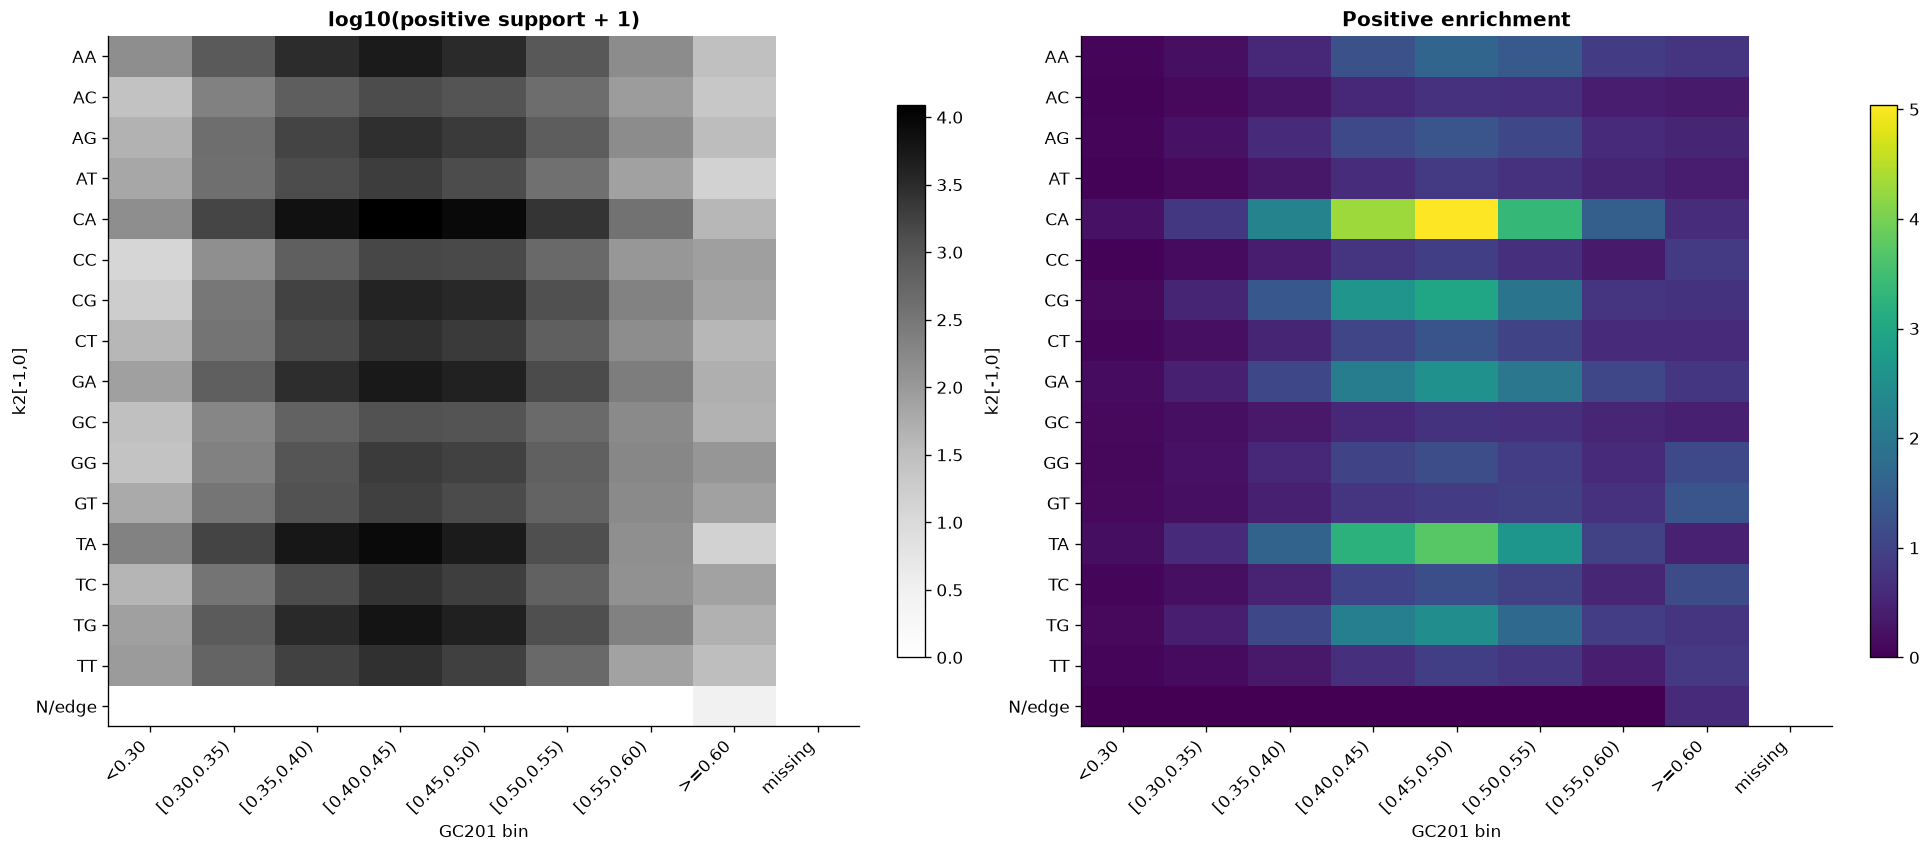

In [8]:
train_interaction_enrichment = interaction_enrichment_table(
    train_gc_counts,
    design=hierarchical_kmer_design(CONFIG),
)
display(
    train_interaction_enrichment.sort_values(
        ["positives", "positions"], ascending=False
    ).head(40)
)

support_heatmap = train_interaction_enrichment.pivot(
    index="k2", columns="gc_bin", values="positives"
).reindex(index=K2_LABELS, columns=GC_BIN_LABELS)
enrichment_heatmap = train_interaction_enrichment.pivot(
    index="k2", columns="gc_bin", values="enrichment"
).reindex(index=K2_LABELS, columns=GC_BIN_LABELS)

fig_train_interactions, axes = plt.subplots(
    1, 2, figsize=(16, 7), constrained_layout=True
)
images = [
    axes[0].imshow(np.log10(support_heatmap.to_numpy() + 1), aspect="auto", cmap="Greys"),
    axes[1].imshow(enrichment_heatmap.to_numpy(), aspect="auto", cmap="viridis"),
]
titles = ["log10(positive support + 1)", "Positive enrichment"]
for ax, image, title in zip(axes, images, titles):
    ax.set_xticks(range(len(GC_BIN_LABELS)), GC_BIN_LABELS, rotation=45, ha="right")
    ax.set_yticks(range(len(K2_LABELS)), K2_LABELS)
    ax.set_title(title)
    ax.set_xlabel("GC201 bin")
    ax.set_ylabel("k2[-1,0]")
    fig_train_interactions.colorbar(image, ax=ax, shrink=0.8)
plt.show()


In [9]:
design = hierarchical_kmer_design(CONFIG)
train_aggregate_preview = aggregate_gc_interaction_likelihood(
    train_gc_counts,
    design,
    config=CONFIG,
)
aggregate_report = pd.Series({
    "EXP-007_main_effect_columns": 4379,
    "interaction_columns": len(interaction_feature_table(CONFIG)),
    "candidate_columns": train_aggregate_preview.matrix.shape[1],
    "aggregate_binary_rows": len(train_aggregate_preview.rows),
    "represented_positions": int(train_aggregate_preview.rows["population_count"].sum()),
    "matrix_memory_mib": (
        train_aggregate_preview.matrix.data.nbytes
        + train_aggregate_preview.matrix.indices.nbytes
        + train_aggregate_preview.matrix.indptr.nbytes
    ) / 2**20,
}, name="value").to_frame()
display(aggregate_report)
assert train_aggregate_preview.matrix.shape[1] == 4507
assert int(train_aggregate_preview.rows["population_count"].sum()) == expected_train
del train_aggregate_preview


,value
EXP-007_main_effect_columns,4.379000e+03
interaction_columns,1.280000e+02
candidate_columns,4.507000e+03
aggregate_binary_rows,5.341590e+05
represented_positions,2.280642e+08
matrix_memory_mib,3.078730e+01


In [10]:
cv_plan = pd.Series({
    "folds": CONFIG.cv_folds,
    "C_values": len(CONFIG.C_grid),
    "planned_fits": CONFIG.cv_folds * len(CONFIG.C_grid),
    "C_grid": CONFIG.C_grid,
    "max_iter": CONFIG.max_iter,
    "tol": CONFIG.tol,
    "threadpoolctl_during_fit": False,
}, name="value").to_frame()
display(cv_plan)
assert CONFIG.cv_folds * len(CONFIG.C_grid) == 15


,value
folds,3
C_values,5
planned_fits,15
C_grid,"(0.0001, 0.0002, 0.0003, 0.0005, 0.001)"
max_iter,2000
tol,0.0
threadpoolctl_during_fit,False


# STOP 1 — дальше ровно 15 обучений

До этой точки модели не обучались. Проверьте heatmaps, support редких
сочетаний, `candidate_columns=4507` и grid из пяти `C`. Следующая ячейка
напечатает фактический прогресс `1/15…15/15`.


In [11]:
started = time.monotonic()
cv_results = cross_validate_gc_interaction_logistic(
    train_gc_counts,
    fold_assignment,
    config=CONFIG,
    verbose=True,
)
cv_seconds = time.monotonic() - started
assert len(cv_results) == 15
print(f"Train-only CV finished in {cv_seconds:.2f} s")
display(cv_results.head())


[01/15] fold=0 C=0.0001 AP=0.002573332 iter=220 time=4.38s converged=True
[02/15] fold=0 C=0.0002 AP=0.002577403 iter=287 time=5.48s converged=True
[03/15] fold=0 C=0.0003 AP=0.002576152 iter=359 time=6.76s converged=True
[04/15] fold=0 C=0.0005 AP=0.002571625 iter=426 time=8.30s converged=True
[05/15] fold=0 C=0.001 AP=0.002565052 iter=577 time=11.12s converged=True
[06/15] fold=1 C=0.0001 AP=0.002169730 iter=215 time=4.28s converged=True
[07/15] fold=1 C=0.0002 AP=0.002175886 iter=314 time=6.20s converged=True
[08/15] fold=1 C=0.0003 AP=0.002176581 iter=360 time=7.30s converged=True
[09/15] fold=1 C=0.0005 AP=0.002174772 iter=419 time=7.95s converged=True
[10/15] fold=1 C=0.001 AP=0.002171555 iter=569 time=11.05s converged=True
[11/15] fold=2 C=0.0001 AP=0.002234447 iter=228 time=4.47s converged=True
[12/15] fold=2 C=0.0002 AP=0.002241932 iter=296 time=5.91s converged=True
[13/15] fold=2 C=0.0003 AP=0.002243540 iter=346 time=6.75s converged=True
[14/15] fold=2 C=0.0005 AP=0.002241805

,C,fold,validation_contigs,segment,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence,iterations,converged,fit_seconds,aggregate_rows,warnings,interaction_coefficient_0,interaction_coefficient_1,interaction_coefficient_2,interaction_coefficient_3,interaction_coefficient_4,interaction_coefficient_5,interaction_coefficient_6,interaction_coefficient_7,interaction_coefficient_8,interaction_coefficient_9,interaction_coefficient_10,interaction_coefficient_11,interaction_coefficient_12,interaction_coefficient_13,interaction_coefficient_14,interaction_coefficient_15,interaction_coefficient_16,interaction_coefficient_17,interaction_coefficient_18,interaction_coefficient_19,interaction_coefficient_20,interaction_coefficient_21,interaction_coefficient_22,...,interaction_coefficient_88,interaction_coefficient_89,interaction_coefficient_90,interaction_coefficient_91,interaction_coefficient_92,interaction_coefficient_93,interaction_coefficient_94,interaction_coefficient_95,interaction_coefficient_96,interaction_coefficient_97,interaction_coefficient_98,interaction_coefficient_99,interaction_coefficient_100,interaction_coefficient_101,interaction_coefficient_102,interaction_coefficient_103,interaction_coefficient_104,interaction_coefficient_105,interaction_coefficient_106,interaction_coefficient_107,interaction_coefficient_108,interaction_coefficient_109,interaction_coefficient_110,interaction_coefficient_111,interaction_coefficient_112,interaction_coefficient_113,interaction_coefficient_114,interaction_coefficient_115,interaction_coefficient_116,interaction_coefficient_117,interaction_coefficient_118,interaction_coefficient_119,interaction_coefficient_120,interaction_coefficient_121,interaction_coefficient_122,interaction_coefficient_123,interaction_coefficient_124,interaction_coefficient_125,interaction_coefficient_126,interaction_coefficient_127
0,0.0001,0,"NC_064035.1,NC_064043.1,NC_064048.1","NC_064035.1,NC_064043.1,NC_064048.1",EXP-008 LR + k2 x GC-bin,0.002573,0.089537,0.594201,0.591853,75423552,61433,0.000815,220,True,4.375,494092,,-0.176337,-0.155007,0.052593,0.072830,0.204664,0.184848,-0.000084,0.0,-0.066491,0.069342,-0.028246,0.035859,0.153689,0.274476,0.069271,0.0,-0.254550,-0.007196,-0.023322,-0.076384,-0.030082,-0.006817,-0.178036,...,0.264351,0.030934,-0.132057,-0.204694,0.106518,0.350617,0.617880,0.0,-0.349227,-0.125429,0.093552,0.005808,-0.139700,-0.396479,-0.496449,0.0,-0.044915,-0.086901,0.010821,-0.044999,-0.022520,0.112237,0.376189,0.0,-0.211823,-0.011243,0.070273,-0.036070,-0.095084,-0.203652,-0.309820,0.0,-0.007784,-0.014029,-0.072091,-0.076932,-0.051011,-0.015642,-0.028194,0.0
1,0.0001,1,"NC_064036.1,NC_064038.1,NC_064045.1","NC_064036.1,NC_064038.1,NC_064045.1",EXP-008 LR + k2 x GC-bin,0.002170,0.084794,0.593521,0.597602,77195444,56300,0.000729,215,True,4.282,494517,,-0.048802,-0.125300,0.118691,0.116706,0.132100,0.170155,0.036480,0.0,-0.069196,0.050606,-0.042824,-0.005978,0.119045,0.186569,0.100250,0.0,-0.028396,-0.009601,-0.037444,-0.101751,-0.065739,-0.043314,-0.150184,...,0.148932,0.060780,-0.140794,-0.182854,0.049948,0.281844,0.469723,0.0,-0.416879,-0.107340,0.113660,0.018060,-0.068177,-0.311748,-0.420839,0.0,-0.128687,-0.022764,0.081195,-0.012671,0.046313,0.023605,0.415791,0.0,-0.330632,-0.099772,0.084794,-0.042558,-0.186634,-0.159544,-0.240899,0.0,-0.010291,-0.012223,-0.060564,-0.058585,-0.046932,-0.012958,0.059293,0.0
2,0.0001,2,"NC_064039.1,NC_064040.1,NC_064047.1","NC_064039.1,NC_064040.1,NC_064047.1",EXP-008 LR + k2 x GC-bin,0.002234,0.089472,0.592909,0.590299,75445164,52710,0.000699,228,True,4.469,498235,,-0.091254,-0.137511,0.130671,0.141976,0.165681,0.261845,0.016732,0.0,0.055837,0.027433,-0.013954,-0.059422,0.175502,0.115121,-0.103954,0.0,-0.069468,0.090611,-0.030941,-0.092342,-0.069103,0.000769,-0.127109,...,0.306399,0.099194,-0.115744,-0.194556,0.116330,0.357238,0.637765,0.0,-0.312752,-0.097941,0.078050,-0.016681,-0.113639,-0.439500,-0.403986,

In [12]:
cv_summary = summarise_cv(cv_results)
nonconverged = cv_summary.loc[~cv_summary["all_folds_converged"].astype(bool)]
display(cv_summary.style.format({
    "mean_average_precision": "{:.9f}",
    "std_average_precision": "{:.9f}",
    "mean_epic_spearman": "{:.6f}",
    "std_epic_spearman": "{:.6f}",
    "mean_balanced_log_loss": "{:.6f}",
    "total_fit_seconds": "{:.2f}",
}))
if len(nonconverged):
    display(Markdown(
        "**Несошедшиеся C исключаются из выбора:** "
        + ", ".join(map(str, nonconverged["C"]))
    ))
assert cv_summary["all_folds_converged"].any(), "Ни один C не сошёлся"


,C,mean_average_precision,std_average_precision,mean_epic_spearman,std_epic_spearman,mean_balanced_log_loss,all_folds_converged,max_iterations,total_fit_seconds
0,0.000100,0.002325836,0.000216766,0.087935,0.002720,0.593252,True,228,13.13
1,0.000200,0.002331740,0.000215298,0.089085,0.002448,0.593115,True,314,17.59
2,0.000300,0.002332091,0.000213998,0.089579,0.002292,0.593282,True,360,20.81
3,0.000500,0.002329401,0.000212433,0.090035,0.002104,0.593675,True,452,25.01
4,0.001000,0.002324567,0.000210829,0.090401,0.001910,0.594328,True,595,33.61


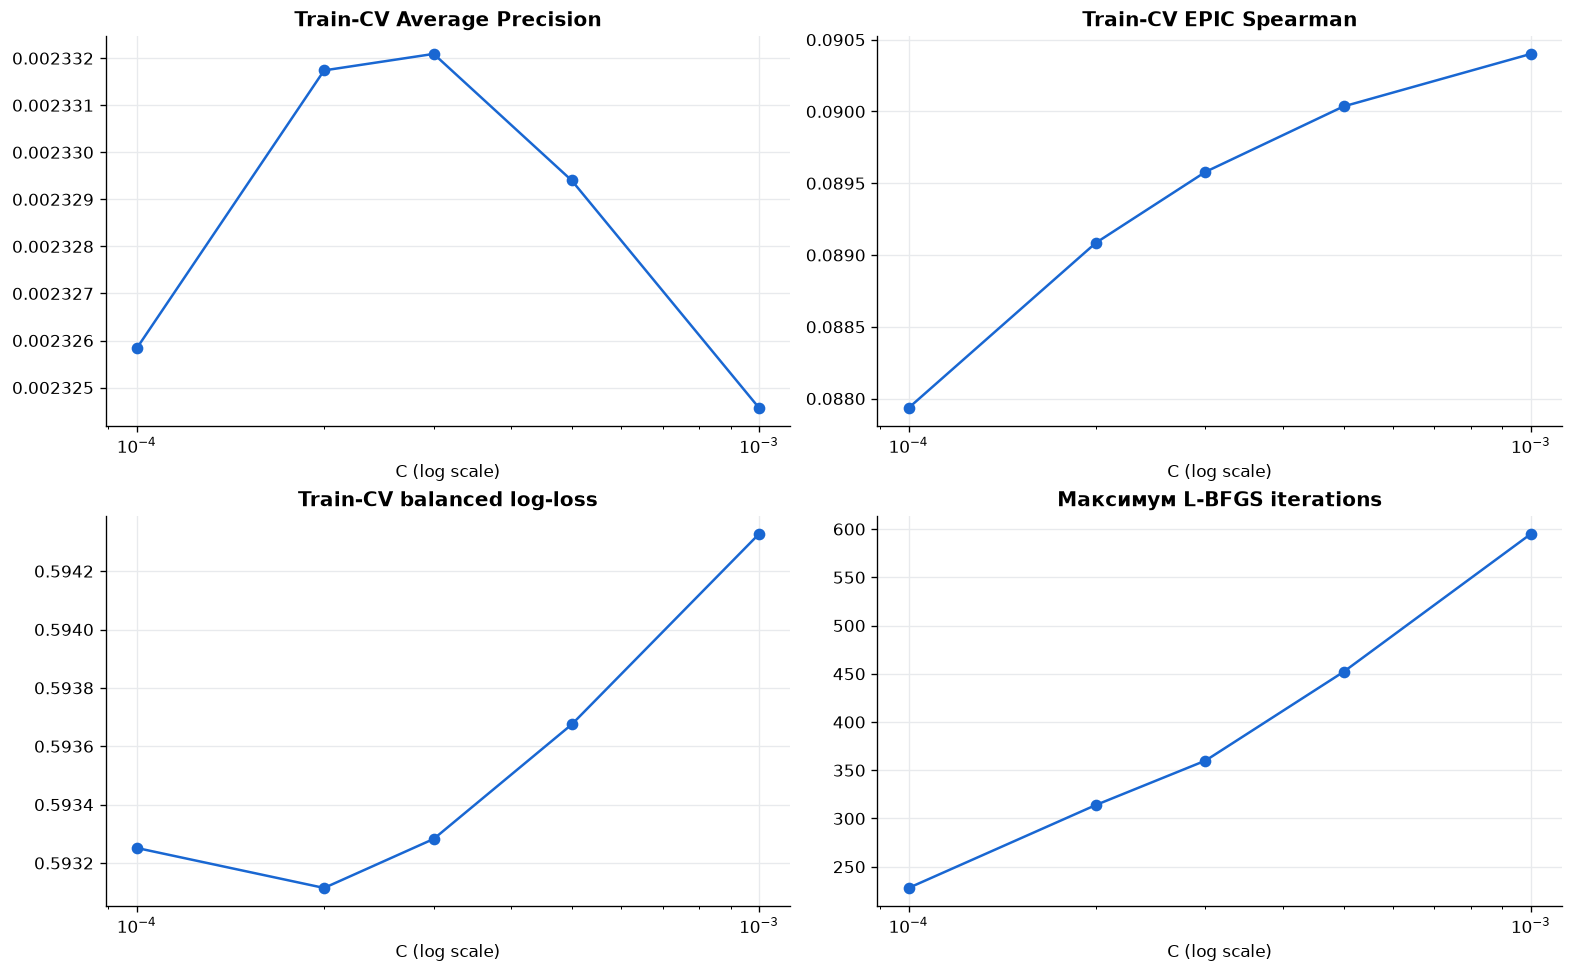

In [13]:
fig_cv, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
panels = [
    ("mean_average_precision", "Train-CV Average Precision", axes[0, 0]),
    ("mean_epic_spearman", "Train-CV EPIC Spearman", axes[0, 1]),
    ("mean_balanced_log_loss", "Train-CV balanced log-loss", axes[1, 0]),
    ("max_iterations", "Максимум L-BFGS iterations", axes[1, 1]),
]
for column, title, ax in panels:
    ax.plot(cv_summary["C"], cv_summary[column], marker="o", color="#1967D2")
    failed = ~cv_summary["all_folds_converged"].astype(bool)
    ax.scatter(
        cv_summary.loc[failed, "C"],
        cv_summary.loc[failed, column],
        color="#D93025",
        label="not converged",
        zorder=3,
    )
    ax.set_xscale("log")
    ax.set_xlabel("C (log scale)")
    ax.set_title(title)
    ax.grid(color="#E8EAED")
    if failed.any():
        ax.legend(frameon=False)
plt.show()


In [14]:
selected = select_regularization(
    cv_summary,
    relative_ap_tolerance=CONFIG.near_best_relative_ap,
)
SELECTED_C = float(selected["C"])
display(selected.to_frame("selected_value"))
print(f"Frozen candidate C before validation: {SELECTED_C:g}")


,selected_value
C,0.0003
mean_average_precision,0.002332
std_average_precision,0.000214
mean_epic_spearman,0.089579
std_epic_spearman,0.002292
mean_balanced_log_loss,0.593282
all_folds_converged,True
max_iterations,360
total_fit_seconds,20.812


Frozen candidate C before validation: 0.0003


,fold,validation_contigs,candidate_average_precision,candidate_epic_spearman,candidate_converged,exp007_average_precision,exp007_epic_spearman,ap_delta,relative_ap_delta,spearman_delta
0,0,"NC_064035.1,NC_064043.1,NC_064048.1",0.002576152,0.090661,True,0.002579426,0.090699,-0.000003273,-0.13%,-0.000038
1,1,"NC_064036.1,NC_064038.1,NC_064045.1",0.002176581,0.086946,True,0.002167184,0.085675,+0.000009396,+0.43%,+0.001271
2,2,"NC_064039.1,NC_064040.1,NC_064047.1",0.002243540,0.091131,True,0.002224279,0.089957,+0.000019261,+0.87%,+0.001174


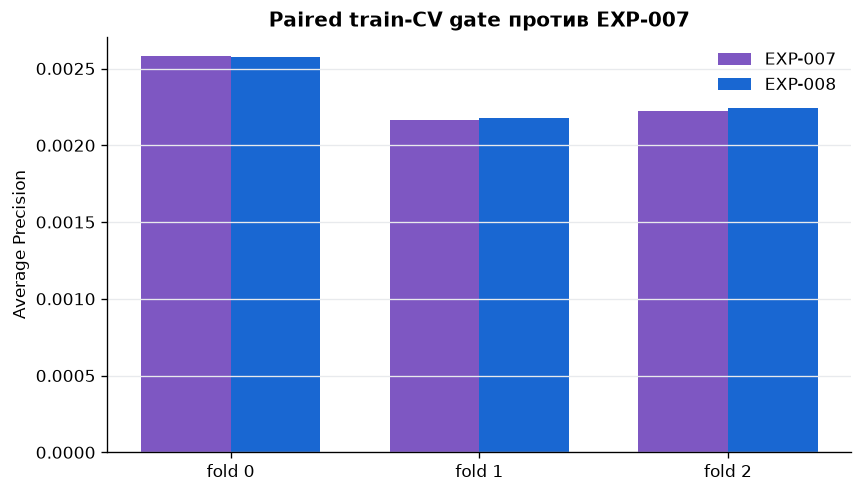

CV gate passed: False


In [15]:
EXP007_DIR = PROJECT_ROOT / "artifacts/experiments/EXP-007/run_001"
exp007_metadata = json.loads((EXP007_DIR / "metadata.json").read_text(encoding="utf-8"))
exp007_cv_results = pd.read_csv(EXP007_DIR / "cv_results.csv")
EXP007_SELECTED_C = float(exp007_metadata["parameters"]["selected_C"])

candidate_cv_selected = cv_results.loc[
    np.isclose(cv_results["C"], SELECTED_C),
    ["fold", "validation_contigs", "average_precision", "epic_spearman", "converged"],
].rename(columns={
    "average_precision": "candidate_average_precision",
    "epic_spearman": "candidate_epic_spearman",
    "converged": "candidate_converged",
})
exp007_cv_selected = exp007_cv_results.loc[
    np.isclose(exp007_cv_results["C"], EXP007_SELECTED_C),
    ["fold", "average_precision", "epic_spearman"],
].rename(columns={
    "average_precision": "exp007_average_precision",
    "epic_spearman": "exp007_epic_spearman",
})
paired_cv_gate = candidate_cv_selected.merge(
    exp007_cv_selected, on="fold", validate="one_to_one"
)
paired_cv_gate["ap_delta"] = (
    paired_cv_gate["candidate_average_precision"]
    - paired_cv_gate["exp007_average_precision"]
)
paired_cv_gate["relative_ap_delta"] = (
    paired_cv_gate["candidate_average_precision"]
    / paired_cv_gate["exp007_average_precision"] - 1
)
paired_cv_gate["spearman_delta"] = (
    paired_cv_gate["candidate_epic_spearman"]
    - paired_cv_gate["exp007_epic_spearman"]
)
display(paired_cv_gate.style.format({
    "candidate_average_precision": "{:.9f}",
    "exp007_average_precision": "{:.9f}",
    "ap_delta": "{:+.9f}",
    "relative_ap_delta": "{:+.2%}",
    "candidate_epic_spearman": "{:.6f}",
    "exp007_epic_spearman": "{:.6f}",
    "spearman_delta": "{:+.6f}",
}))
CV_GATE_PASSED = bool(
    paired_cv_gate["candidate_converged"].all()
    and (paired_cv_gate["ap_delta"] > 0).all()
    and paired_cv_gate["candidate_epic_spearman"].mean()
        >= paired_cv_gate["exp007_epic_spearman"].mean()
)

fig_paired_cv, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(paired_cv_gate))
width = 0.36
ax.bar(x - width/2, paired_cv_gate["exp007_average_precision"], width,
       label="EXP-007", color="#7E57C2")
ax.bar(x + width/2, paired_cv_gate["candidate_average_precision"], width,
       label="EXP-008", color="#1967D2")
ax.set_xticks(x, [f"fold {value}" for value in paired_cv_gate["fold"]])
ax.set_ylabel("Average Precision")
ax.set_title("Paired train-CV gate против EXP-007")
ax.legend(frameon=False)
ax.grid(axis="y", color="#E8EAED")
plt.show()
print("CV gate passed:", CV_GATE_PASSED)


,interaction_index,k2,gc_bin,mean_coefficient,std_coefficient,min_coefficient,max_coefficient,mean_absolute_coefficient
38,38,CA,>=0.60,-1.013728,0.149344,-1.154600,-0.857152,1.013728
102,102,TA,>=0.60,-0.850641,0.085041,-0.942102,-0.773956,0.850641
94,94,GT,>=0.60,0.776807,0.091010,0.682082,0.863580,0.776807
54,54,CG,>=0.60,-0.674183,0.047480,-0.719775,-0.625017,0.674183
53,53,CG,"[0.55,0.60)",-0.566557,0.075917,-0.649392,-0.500298,0.566557
110,110,TC,>=0.60,0.551822,0.071819,0.468998,0.596857,0.551822
32,32,CA,<0.30,-0.533728,0.039430,-0.574953,-0.496380,0.533728
46,46,CC,>=0.60,0.505845,0.081480,0.416410,0.575861,0.505845
101,101,TA,"[0.55,0.60)",-0.493657,0.077039,-0.574479,-0.421061,0.493657
86,86,GG,>=0.60,0.471696,0.030362,0.450086,0.506409,0.471696


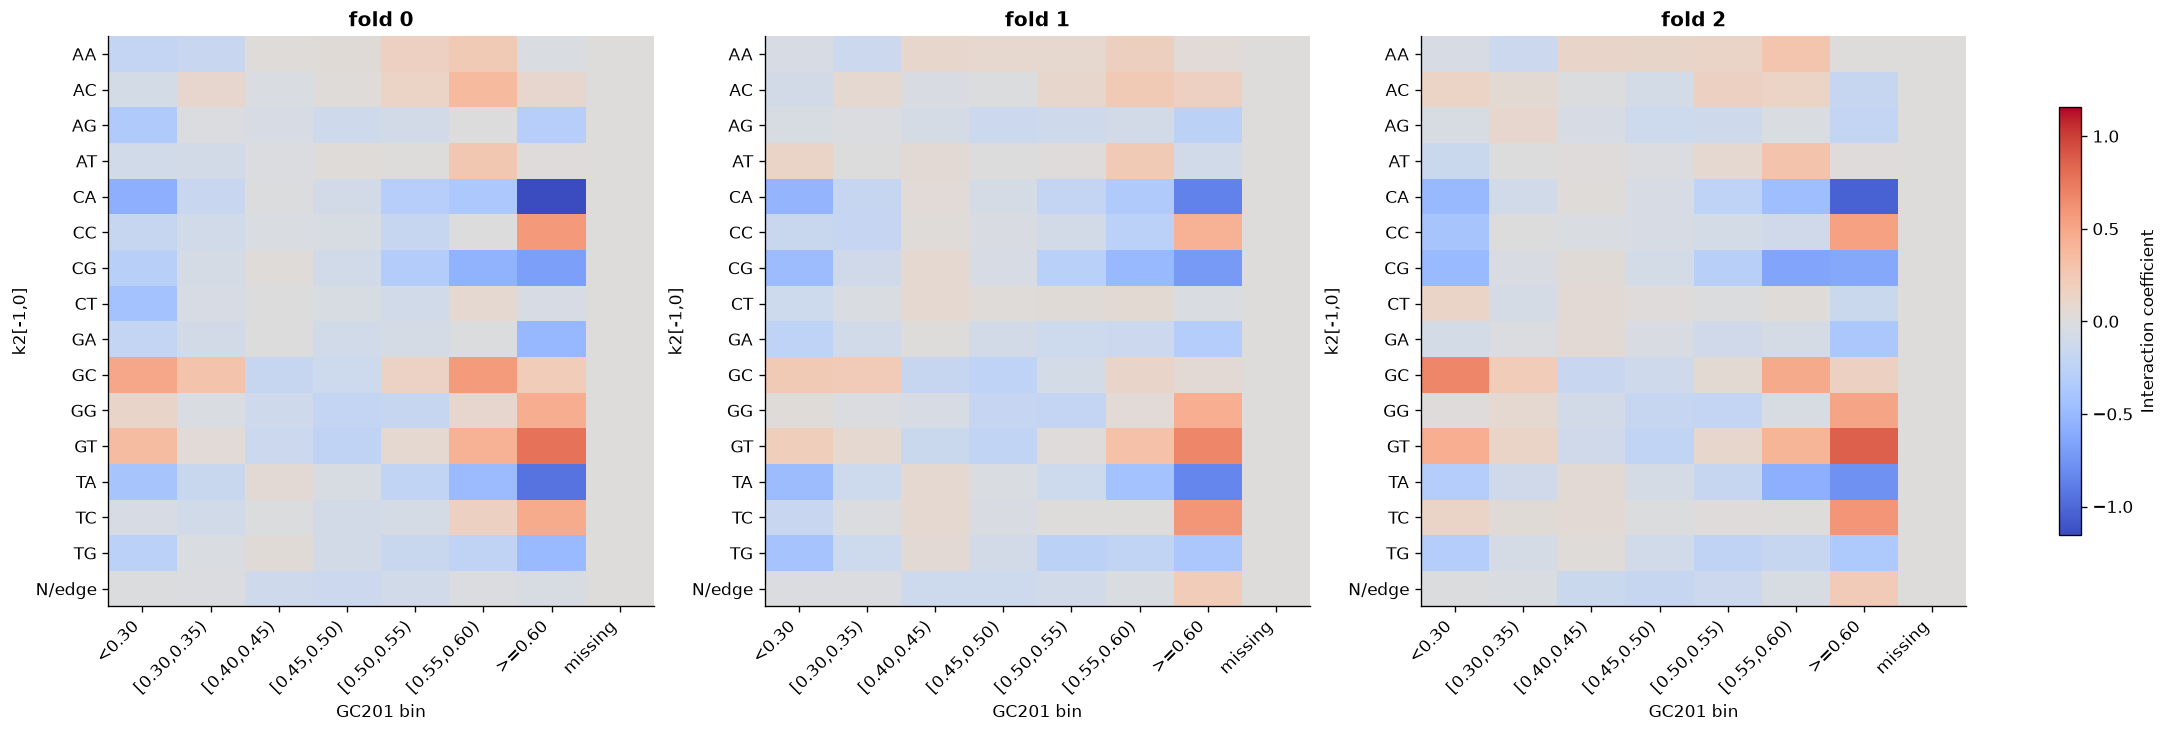

In [16]:
selected_cv_interaction_coefs = selected_cv_interaction_coefficients(
    cv_results,
    C=SELECTED_C,
    config=CONFIG,
)
interaction_stability = (
    selected_cv_interaction_coefs
    .groupby(["interaction_index", "k2", "gc_bin"], as_index=False)
    .agg(
        mean_coefficient=("coefficient", "mean"),
        std_coefficient=("coefficient", "std"),
        min_coefficient=("coefficient", "min"),
        max_coefficient=("coefficient", "max"),
    )
)
interaction_stability["mean_absolute_coefficient"] = interaction_stability[
    "mean_coefficient"
].abs()
display(interaction_stability.nlargest(30, "mean_absolute_coefficient"))

fig_cv_interactions, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
coefficient_limit = selected_cv_interaction_coefs["coefficient"].abs().max()
nonreference_k2 = [label for label in K2_LABELS if label != "TT"]
nonreference_gc = [label for label in GC_BIN_LABELS if label != "[0.35,0.40)"]
for ax, (fold, frame) in zip(axes, selected_cv_interaction_coefs.groupby("fold")):
    pivot = frame.pivot(index="k2", columns="gc_bin", values="coefficient").reindex(
        index=nonreference_k2, columns=nonreference_gc
    )
    image = ax.imshow(
        pivot.to_numpy(), aspect="auto", cmap="coolwarm",
        vmin=-coefficient_limit, vmax=coefficient_limit,
    )
    ax.set_xticks(range(len(nonreference_gc)), nonreference_gc, rotation=45, ha="right")
    ax.set_yticks(range(len(nonreference_k2)), nonreference_k2)
    ax.set_title(f"fold {fold}")
    ax.set_xlabel("GC201 bin")
    ax.set_ylabel("k2[-1,0]")
fig_cv_interactions.colorbar(image, ax=axes, shrink=0.75, label="Interaction coefficient")
plt.show()


# STOP 2 — paired CV gate

Проверьте AP каждого fold, mean Spearman и три heatmap interaction.
Если строгий gate не пройден, EXP-008 нельзя автоматически принять.
После явного решения можно один раз довести уже зафиксированный
candidate до validation в режиме `exploratory_after_failed_cv_gate`,
чтобы отрицательный эксперимент также был полностью сохранён.


In [19]:
ALLOW_EXPLORATORY_COMPLETION = True
PROTOCOL_STATUS = (
    "confirmatory"
    if CV_GATE_PASSED
    else "exploratory_after_failed_cv_gate"
)
if not CV_GATE_PASSED:
    assert ALLOW_EXPLORATORY_COMPLETION
    display(Markdown(
        "**CV gate не пройден.** Продолжаем ровно один раз только для "
        "сохранения полного отрицательного результата. Такой run не "
        "может получить решение `adopt`."
    ))
print("Protocol status:", PROTOCOL_STATUS)


**CV gate не пройден.** Продолжаем ровно один раз только для сохранения полного отрицательного результата. Такой run не может получить решение `adopt`.

Protocol status: exploratory_after_failed_cv_gate


In [20]:
print(f"Starting full-train fit with C={SELECTED_C:g} ...", flush=True)
started = time.monotonic()
final_fit = fit_gc_interaction_logistic(
    train_gc_counts,
    C=SELECTED_C,
    config=CONFIG,
    design=design,
)
full_fit_seconds = time.monotonic() - started
display(final_fit.fit_report)
assert bool(final_fit.fit_report.iloc[0]["converged"]), (
    "Final candidate did not converge; do not open validation."
)
print(f"Full-train candidate fit in {full_fit_seconds:.2f} s")


Starting full-train fit with C=0.0003 ...


,C,solver,penalty,tol,iterations,max_iter,converged,fit_seconds,aggregate_rows,features,interaction_features,represented_positions,represented_positives,reference_k2,reference_gc_bin,intercept,warnings
0,0.0003,lbfgs,l2,1.000000e-08,410,2000,True,8.75,534159,4507,128,228064160,170443,TT,"[0.35,0.40)",-0.527141,


Full-train candidate fit in 9.61 s


In [21]:
final_interactions = interaction_feature_table(CONFIG).merge(
    final_fit.coefficient_table[
        ["feature_name", "coefficient", "absolute_coefficient"]
    ],
    on="feature_name",
    validate="one_to_one",
)
final_interactions["odds_multiplier"] = np.exp(final_interactions["coefficient"])
display(final_interactions.nlargest(30, "absolute_coefficient"))

final_interaction_heatmap = final_interactions.pivot(
    index="k2", columns="gc_bin", values="coefficient"
).reindex(index=nonreference_k2, columns=nonreference_gc)


,interaction_index,k2_code,k2,gc_bin_code,gc_bin,feature_name,feature_group,coefficient,absolute_coefficient,odds_multiplier
38,38,4,CA,7,>=0.60,k2=CA x gc201_bin=>=0.60,k2 x GC201 bin,-1.131829,1.131829,0.322443
102,102,12,TA,7,>=0.60,k2=TA x gc201_bin=>=0.60,k2 x GC201 bin,-1.018138,1.018138,0.361267
94,94,11,GT,7,>=0.60,k2=GT x gc201_bin=>=0.60,k2 x GC201 bin,0.811143,0.811143,2.250479
54,54,6,CG,7,>=0.60,k2=CG x gc201_bin=>=0.60,k2 x GC201 bin,-0.744004,0.744004,0.475207
53,53,6,CG,6,"[0.55,0.60)","k2=CG x gc201_bin=[0.55,0.60)",k2 x GC201 bin,-0.599304,0.599304,0.549194
110,110,13,TC,7,>=0.60,k2=TC x gc201_bin=>=0.60,k2 x GC201 bin,0.560772,0.560772,1.752024
32,32,4,CA,0,<0.30,k2=CA x gc201_bin=<0.30,k2 x GC201 bin,-0.551730,0.551730,0.575952
101,101,12,TA,6,"[0.55,0.60)","k2=TA x gc201_bin=[0.55,0.60)",k2 x GC201 bin,-0.530381,0.530381,0.588381
46,46,5,CC,7,>=0.60,k2=CC x gc201_bin=>=0.60,k2 x GC201 bin,0.517689,0.517689,1.678144
72,72,9,GC,0,<0.30,k2=GC x gc201_bin=<0.30,k2 x GC201 bin,0.512040,0.512040,1.668692


# STOP 3 — зафиксированный одноразовый validation

Зафиксированы vocabulary из 128 interactions, grid из пяти `C`,
выбранный `C`, результат paired gate, protocol status и final fit.
Если CV gate не пройден, validation интерпретируется только как
exploratory. После следующей ячейки ничего менять нельзя; новая
настройка потребует EXP-009.


In [22]:
started = time.monotonic()
validation_gc_counts = split_kmer_gc_counts(
    split,
    sequences,
    "validation",
    config=CONFIG,
)
validation_count_seconds = time.monotonic() - started
validation_gc_diagnostics = gc_count_diagnostics(validation_gc_counts)
validation_kmer_counts = kmer_counts_from_gc_counts(
    validation_gc_counts,
    ks=CONFIG.ks,
)
display(validation_gc_diagnostics)
print(f"Full validation counted in {validation_count_seconds:.2f} s")


,split,aggregate_rows,positions,positives,unique_gc_fractions,zero_valid_positions,zero_valid_fraction,totals_memory_mib,positives_memory_mib
0,validation,2054867,83807486,56205,4950,0,0.0,246.919035,8.040316


Full validation counted in 11.64 s


In [23]:
candidate_evaluation = evaluate_gc_interaction_logistic(
    validation_gc_counts,
    final_fit,
    config=CONFIG,
    variant="EXP-008 LR + k2 x GC-bin",
)
candidate_row = candidate_evaluation.metric_summary.iloc[0]
display(candidate_evaluation.metric_summary)
display(candidate_evaluation.per_contig_metrics)


,segment,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence
0,overall,EXP-008 LR + k2 x GC-bin,0.002064,0.104167,0.596199,0.594664,83807486,56205,0.000671


,contig,variant,average_precision,epic_spearman,population_log_loss,balanced_log_loss,positions,positives,prevalence
0,NC_064034.1,EXP-008 LR + k2 x GC-bin,0.002253,0.123398,0.595625,0.589067,33949114,23529,0.000693
1,NC_064041.1,EXP-008 LR + k2 x GC-bin,0.001722,0.127555,0.594381,0.598311,24146754,13984,0.000579
2,NC_064042.1,EXP-008 LR + k2 x GC-bin,0.002146,0.123670,0.598664,0.599173,25711618,18692,0.000727


In [24]:
lookup_fit = fit_kmer_lookup(train_kmer_counts, LOOKUP_CONFIG)
lookup_evaluation = evaluate_kmer_lookup(validation_kmer_counts, lookup_fit)
exp003_row = lookup_evaluation.metric_summary.loc[
    lookup_evaluation.metric_summary["k"] == 6
].iloc[0]
display(exp003_row.to_frame("EXP-003"))


,EXP-003
segment,overall
segment_value,overall
k,6
variant,6mer_lookup
average_precision,0.001601
epic_spearman,0.097186
positions,83807486
positives,56205
prevalence,0.000671
unique_score_levels,4097


In [25]:
exp007_per_contig = pd.read_csv(EXP007_DIR / "per_contig_metrics.csv")
exp007_pr_all = pd.read_csv(EXP007_DIR / "precision_recall.csv")
exp007_pr = exp007_pr_all.loc[
    exp007_pr_all["variant"] == "EXP-007 binned GC201"
].copy()
exp007_ap = float(exp007_metadata["metrics"]["candidate_average_precision"])
exp007_spearman = float(exp007_metadata["metrics"]["candidate_epic_spearman"])
display(pd.Series({
    "EXP-007 AP": exp007_ap,
    "EXP-007 Spearman": exp007_spearman,
    "EXP-007 decision": exp007_metadata["run"]["decision"],
}, name="value").to_frame())


C:\Users\lasvi\AppData\Local\Temp\ipykernel_31920\270846052.py:2: DtypeWarning: Columns (0: segment) have mixed types. Specify dtype option on import or set low_memory=False.
  exp007_pr_all = pd.read_csv(EXP007_DIR / "precision_recall.csv")


,value
EXP-007 AP,0.002054
EXP-007 Spearman,0.104302
EXP-007 decision,adopt


In [26]:
metric_summary = pd.DataFrame([
    {
        "variant": "EXP-003 6-mer lookup",
        "average_precision": float(exp003_row["average_precision"]),
        "epic_spearman": float(exp003_row["epic_spearman"]),
    },
    {
        "variant": "EXP-007 binned GC201",
        "average_precision": exp007_ap,
        "epic_spearman": exp007_spearman,
    },
    {
        "variant": "EXP-008 k2 x GC-bin",
        "average_precision": float(candidate_row["average_precision"]),
        "epic_spearman": float(candidate_row["epic_spearman"]),
    },
])
display(metric_summary)

exp003_contigs = lookup_evaluation.per_contig_metrics.loc[
    lookup_evaluation.per_contig_metrics["k"] == 6,
    ["segment_value", "average_precision", "epic_spearman"],
].rename(columns={
    "segment_value": "contig",
    "average_precision": "exp003_average_precision",
    "epic_spearman": "exp003_epic_spearman",
})
exp007_contigs = exp007_per_contig.rename(columns={
    "candidate_average_precision": "exp007_average_precision",
    "candidate_epic_spearman": "exp007_epic_spearman",
})[["contig", "exp007_average_precision", "exp007_epic_spearman"]]
candidate_contigs = candidate_evaluation.per_contig_metrics.rename(columns={
    "average_precision": "candidate_average_precision",
    "epic_spearman": "candidate_epic_spearman",
})[["contig", "candidate_average_precision", "candidate_epic_spearman"]]
per_contig_metrics = (
    exp003_contigs
    .merge(exp007_contigs, on="contig", validate="one_to_one")
    .merge(candidate_contigs, on="contig", validate="one_to_one")
)
display(per_contig_metrics)


,variant,average_precision,epic_spearman
0,EXP-003 6-mer lookup,0.001601,0.097186
1,EXP-007 binned GC201,0.002054,0.104302
2,EXP-008 k2 x GC-bin,0.002064,0.104167


,contig,exp003_average_precision,exp003_epic_spearman,exp007_average_precision,exp007_epic_spearman,candidate_average_precision,candidate_epic_spearman
0,NC_064034.1,0.001717,0.109397,0.002241,0.123295,0.002253,0.123398
1,NC_064041.1,0.001381,0.120721,0.001710,0.127176,0.001722,0.127555
2,NC_064042.1,0.001655,0.115426,0.002137,0.123564,0.002146,0.123670


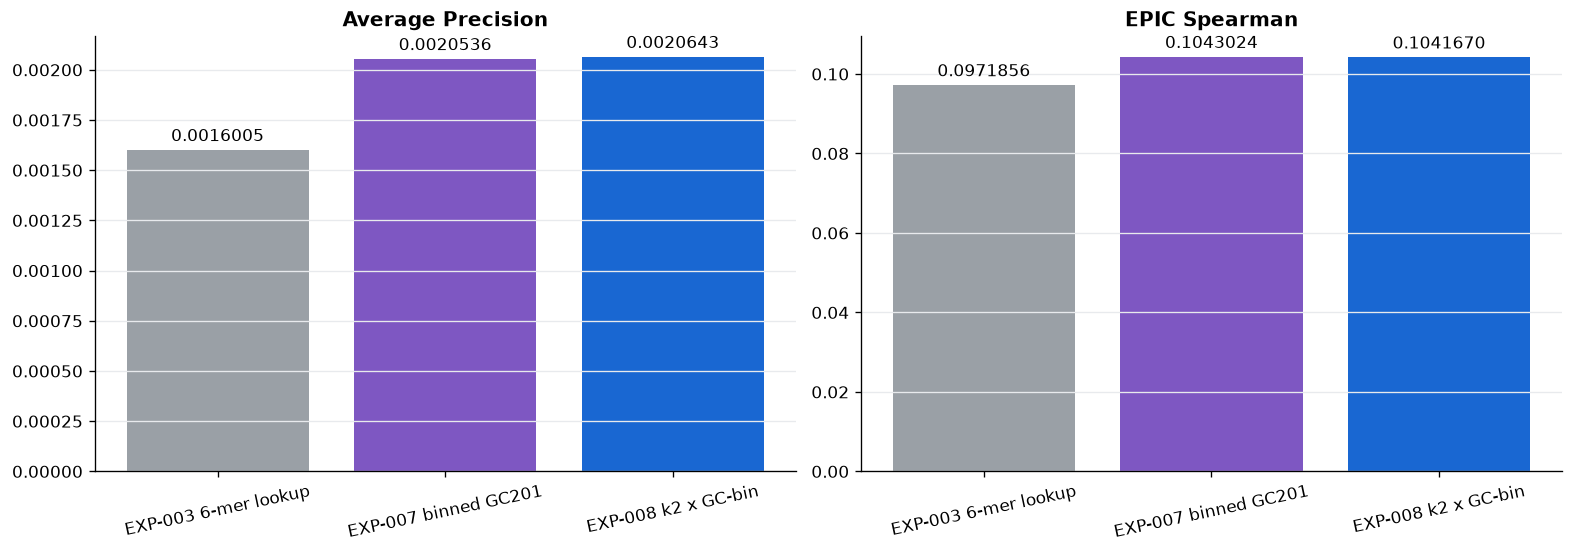

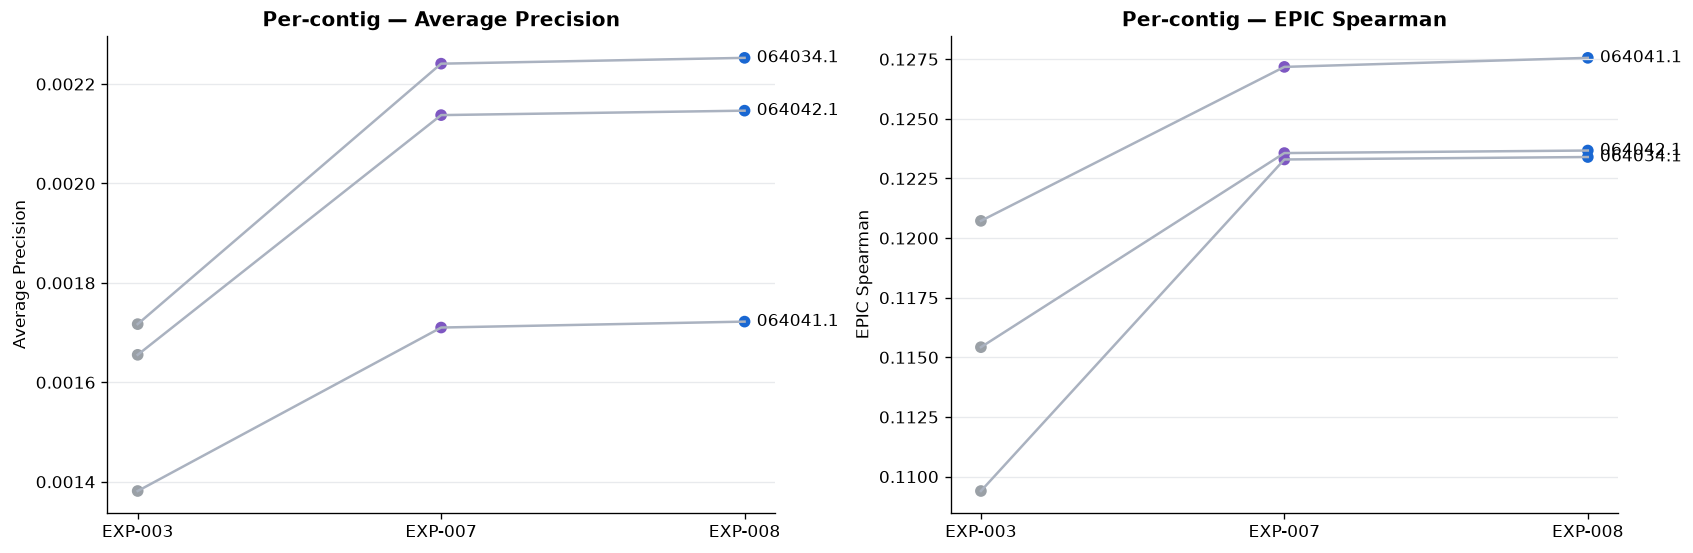

In [27]:
colors = ["#9AA0A6", "#7E57C2", "#1967D2"]
fig_metrics, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, metric, title in [
    (axes[0], "average_precision", "Average Precision"),
    (axes[1], "epic_spearman", "EPIC Spearman"),
]:
    bars = ax.bar(metric_summary["variant"], metric_summary[metric], color=colors)
    ax.bar_label(bars, fmt="%.7f", padding=3)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=12)
    ax.grid(axis="y", color="#E8EAED")
plt.show()

fig_contigs, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for ax, metric, label in [
    (axes[0], "average_precision", "Average Precision"),
    (axes[1], "epic_spearman", "EPIC Spearman"),
]:
    columns = [f"exp003_{metric}", f"exp007_{metric}", f"candidate_{metric}"]
    for _, row in per_contig_metrics.iterrows():
        values = [row[column] for column in columns]
        ax.plot(range(3), values, color="#AAB2C0")
        ax.scatter(range(3), values, color=colors)
        ax.text(2.04, values[-1], row["contig"].replace("NC_", ""), va="center")
    ax.set_xticks(range(3), ["EXP-003", "EXP-007", "EXP-008"])
    ax.set_ylabel(label)
    ax.set_title(f"Per-contig — {label}")
    ax.grid(axis="y", color="#E8EAED")
plt.show()


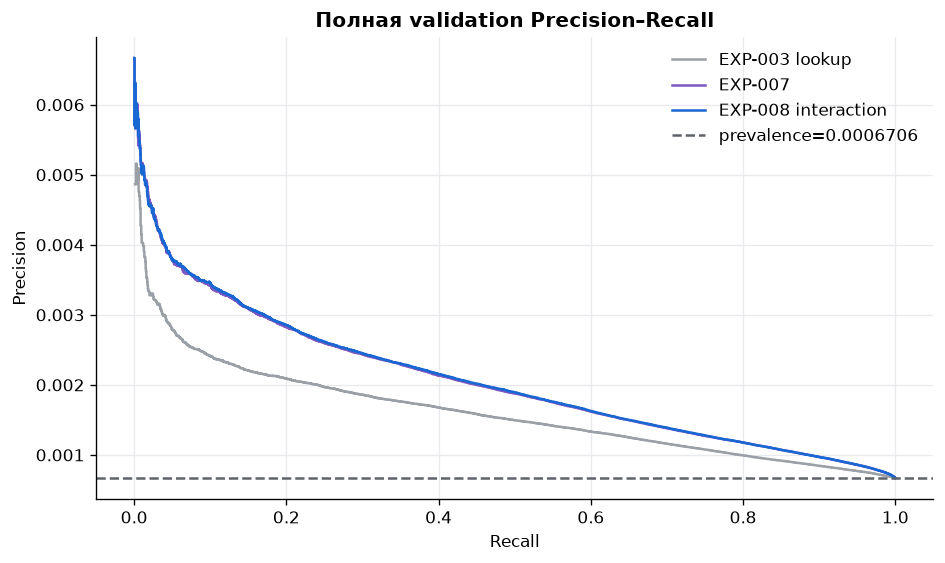

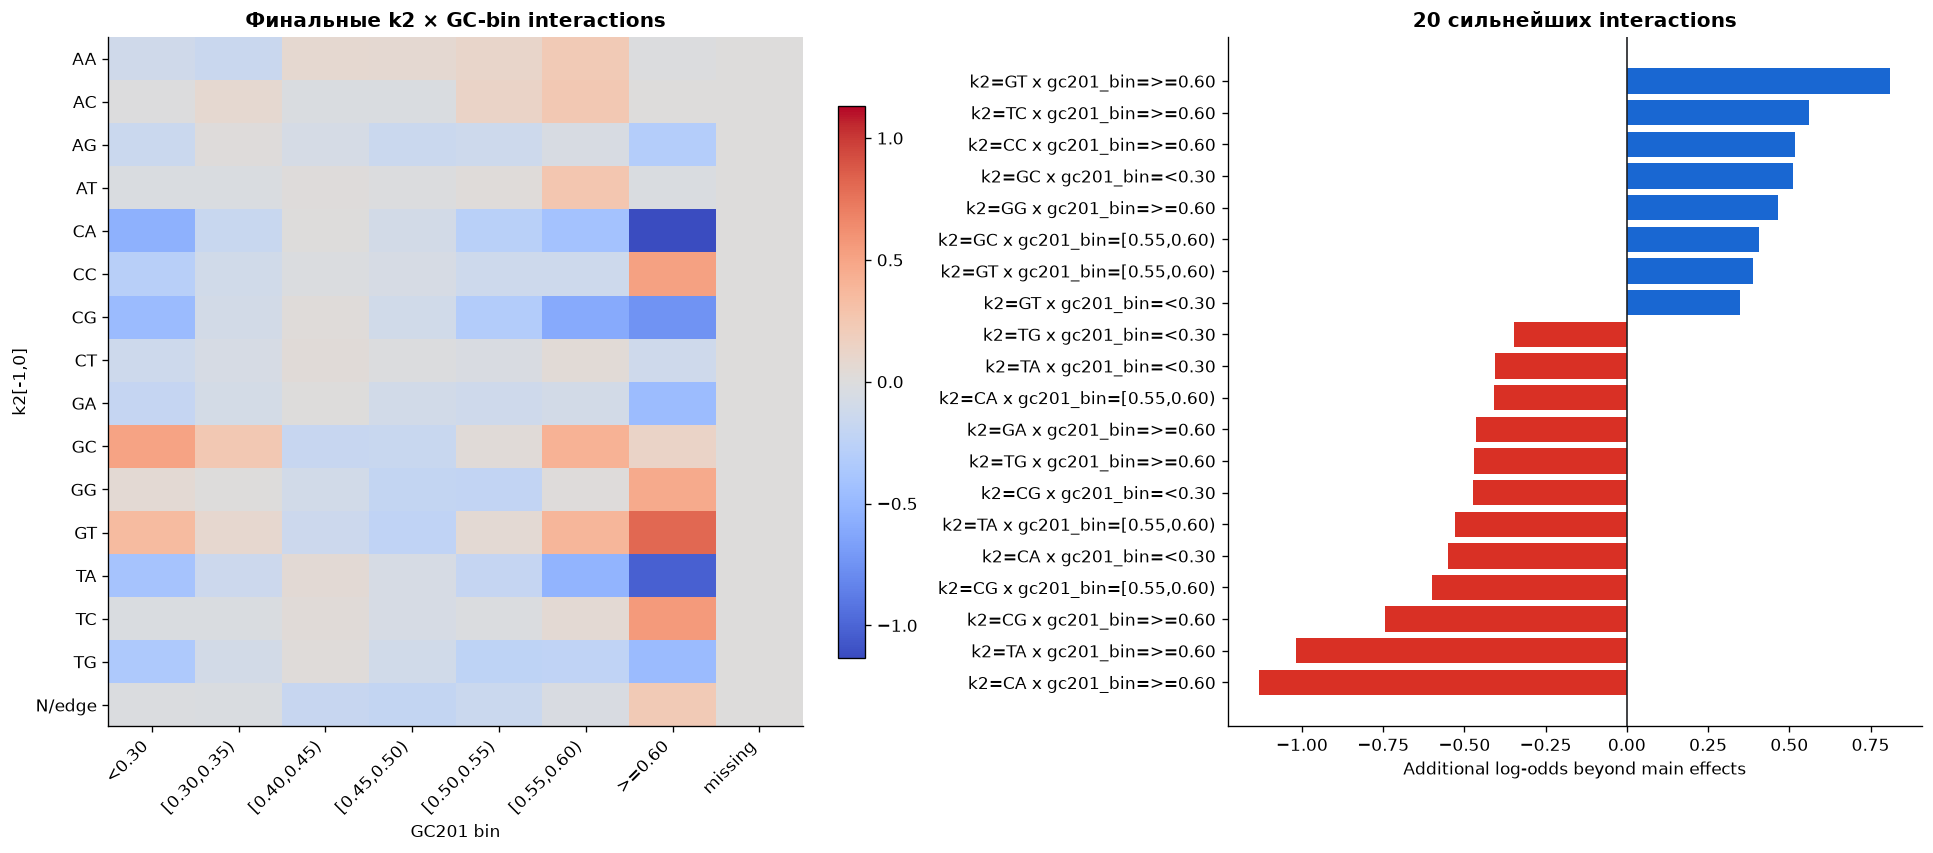

In [28]:
reference_pr = lookup_evaluation.precision_recall.loc[
    lookup_evaluation.precision_recall["k"] == 6
]
candidate_pr = candidate_evaluation.precision_recall
fig_pr, ax = plt.subplots(figsize=(9, 5))
ax.step(reference_pr["recall"], reference_pr["precision"], where="post",
        color="#9AA0A6", label="EXP-003 lookup")
ax.step(exp007_pr["recall"], exp007_pr["precision"], where="post",
        color="#7E57C2", label="EXP-007")
ax.step(candidate_pr["recall"], candidate_pr["precision"], where="post",
        color="#1967D2", label="EXP-008 interaction")
ax.axhline(candidate_row["prevalence"], color="#5F6368", linestyle="--",
           label=f"prevalence={candidate_row['prevalence']:.7f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Полная validation Precision–Recall")
ax.legend(frameon=False)
ax.grid(color="#E8EAED")
plt.show()

strongest = final_interactions.nlargest(20, "absolute_coefficient").sort_values("coefficient")
fig_coefficients, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
limit = np.nanmax(np.abs(final_interaction_heatmap.to_numpy()))
image = axes[0].imshow(
    final_interaction_heatmap.to_numpy(), aspect="auto", cmap="coolwarm",
    vmin=-limit, vmax=limit,
)
axes[0].set_xticks(range(len(nonreference_gc)), nonreference_gc, rotation=45, ha="right")
axes[0].set_yticks(range(len(nonreference_k2)), nonreference_k2)
axes[0].set_title("Финальные k2 × GC-bin interactions")
axes[0].set_xlabel("GC201 bin")
axes[0].set_ylabel("k2[-1,0]")
fig_coefficients.colorbar(image, ax=axes[0], shrink=0.8)
axes[1].barh(
    strongest["feature_name"], strongest["coefficient"],
    color=np.where(strongest["coefficient"] >= 0, "#1967D2", "#D93025"),
)
axes[1].axvline(0, color="#202124", linewidth=1)
axes[1].set_xlabel("Additional log-odds beyond main effects")
axes[1].set_title("20 сильнейших interactions")
plt.show()


## 7. Формальное решение

EXP-007 — новый champion и единственный основной ablation reference.
EXP-003 остаётся исторической точкой отсчёта.


In [29]:
candidate_ap = float(candidate_row["average_precision"])
candidate_spearman = float(candidate_row["epic_spearman"])
exp003_ap = float(exp003_row["average_precision"])
exp003_spearman = float(exp003_row["epic_spearman"])

champion_ap_wins = int((
    per_contig_metrics["candidate_average_precision"]
    > per_contig_metrics["exp007_average_precision"]
).sum())
validation_checks = pd.Series({
    "relative AP gain vs EXP-007 >= 1%": candidate_ap / exp007_ap - 1 >= 0.01,
    "Spearman >= EXP-007": candidate_spearman >= exp007_spearman,
    "AP wins vs EXP-007 on at least 2/3 contigs": champion_ap_wins >= 2,
}, name="passed")
champion_checks = pd.concat([
    pd.Series({"train-CV gate passed": CV_GATE_PASSED}, name="passed"),
    validation_checks,
])
display(Markdown("### Champion gate vs EXP-007"))
display(champion_checks.to_frame())

VALIDATION_CHECKS_PASSED = bool(validation_checks.all())
if CV_GATE_PASSED and VALIDATION_CHECKS_PASSED:
    DECISION = "adopt"
elif VALIDATION_CHECKS_PASSED:
    DECISION = "iterate"
else:
    DECISION = "reject"
INTERPRETATION = (
    f"k2 x GC-bin interactions changed AP vs EXP-007 from {exp007_ap:.9f} "
    f"to {candidate_ap:.9f} ({candidate_ap / exp007_ap - 1:+.2%}) and "
    f"Spearman from {exp007_spearman:.6f} to {candidate_spearman:.6f}; "
    f"vs historical EXP-003 AP change is {candidate_ap / exp003_ap - 1:+.2%}. "
    f"Train-CV gate passed: {CV_GATE_PASSED}; protocol: {PROTOCOL_STATUS}. "
    f"Decision: {DECISION}."
)
display(Markdown(f"**Decision: `{DECISION}`.** {INTERPRETATION}"))


### Champion gate vs EXP-007

,passed
train-CV gate passed,False
relative AP gain vs EXP-007 >= 1%,False
Spearman >= EXP-007,False
AP wins vs EXP-007 on at least 2/3 contigs,True


**Decision: `reject`.** k2 x GC-bin interactions changed AP vs EXP-007 from 0.002053635 to 0.002064290 (+0.52%) and Spearman from 0.104302 to 0.104167; vs historical EXP-003 AP change is +28.97%. Train-CV gate passed: False; protocol: exploratory_after_failed_cv_gate. Decision: reject.

## 8. Сохранение

Только эта ячейка создаёт immutable run `EXP-008/run_001`.


In [30]:
PLOT_DIR.mkdir(parents=True, exist_ok=True)
plot_objects = {
    "01_train_interaction_enrichment.png": fig_train_interactions,
    "02_train_cv_diagnostics.png": fig_cv,
    "03_paired_cv_gate.png": fig_paired_cv,
    "04_cv_interaction_coefficients.png": fig_cv_interactions,
    "05_validation_metrics.png": fig_metrics,
    "06_per_contig_metrics.png": fig_contigs,
    "07_precision_recall.png": fig_pr,
    "08_final_interactions.png": fig_coefficients,
}
for filename, figure in plot_objects.items():
    figure.savefig(PLOT_DIR / filename, dpi=170, bbox_inches="tight", facecolor="white")

criteria_table = champion_checks.rename("passed").to_frame().assign(
    comparison="EXP-007"
).rename_axis("criterion").reset_index()
precision_recall = pd.concat([
    reference_pr.assign(variant="EXP-003 6-mer lookup"),
    exp007_pr.assign(variant="EXP-007 binned GC201"),
    candidate_pr.assign(variant="EXP-008 k2 x GC-bin"),
], ignore_index=True)
tables = {
    "train_gc_diagnostics.csv": train_gc_diagnostics,
    "validation_gc_diagnostics.csv": validation_gc_diagnostics,
    "train_interaction_enrichment.csv": train_interaction_enrichment,
    "cv_fold_assignment.csv": fold_assignment,
    "cv_results.csv": cv_results,
    "cv_summary.csv": cv_summary,
    "paired_cv_gate.csv": paired_cv_gate,
    "selected_cv_interaction_coefficients.csv": selected_cv_interaction_coefs,
    "interaction_stability.csv": interaction_stability,
    "metric_summary.csv": metric_summary,
    "per_contig_metrics.csv": per_contig_metrics,
    "criteria.csv": criteria_table,
    "fit_report.csv": final_fit.fit_report,
    "coefficient_table.csv": final_fit.coefficient_table,
    "final_interactions.csv": final_interactions,
    "precision_recall.csv": precision_recall,
}
for filename, table in tables.items():
    table.to_csv(ARTIFACT_DIR / filename, index=False)
candidate_evaluation.positive_predictions.to_csv(
    ARTIFACT_DIR / "positive_predictions.csv.gz", index=False, compression="gzip"
)

METRICS = {
    "reference_average_precision": exp007_ap,
    "candidate_average_precision": candidate_ap,
    "delta_average_precision": candidate_ap - exp007_ap,
    "reference_epic_spearman": exp007_spearman,
    "candidate_epic_spearman": candidate_spearman,
    "delta_epic_spearman": candidate_spearman - exp007_spearman,
    "historical_exp003_average_precision": exp003_ap,
    "historical_exp003_epic_spearman": exp003_spearman,
    "selected_cv_candidate_mean_average_precision": float(
        paired_cv_gate["candidate_average_precision"].mean()
    ),
    "selected_cv_reference_mean_average_precision": float(
        paired_cv_gate["exp007_average_precision"].mean()
    ),
}
PARAMETERS = CONFIG.to_dict() | {
    "selected_C": SELECTED_C,
    "reference_experiment": "EXP-007/run_001",
    "historical_reference": "EXP-003/run_001",
    "cv_gate": "AP > EXP-007 on every fold and mean Spearman >= EXP-007",
    "cv_gate_passed": CV_GATE_PASSED,
    "allow_exploratory_completion": ALLOW_EXPLORATORY_COMPLETION,
    "protocol_status": PROTOCOL_STATUS,
    "validation_population": "all whitelist positions",
    "validation_used_for_C_selection": False,
    "score": "raw float64 logistic decision_function",
}
record = build_run_record(
    SPEC,
    split,
    run_name=RUN_NAME,
    notebook_path=NOTEBOOK_PATH,
    parameters=PARAMETERS,
    metrics=METRICS,
    interpretation=INTERPRETATION,
    decision=DECISION,
)
output = save_run_record(PROJECT_ROOT, record)
(output / "config.json").write_text(
    json.dumps(PARAMETERS, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
print("Saved run:", output)


Saved run: D:\Projects\EPIC\EPIC\artifacts\experiments\EXP-008\run_001


## 9. Синхронизация отчёта

Финальная ячейка только читает сохранённые артефакты и обновляет
автоматический блок карточки EXP-008.


In [31]:
from ml_project.epic_gc_interaction_report import sync_exp008_report

experiment_note = sync_exp008_report(PROJECT_ROOT, run_name=RUN_NAME)
print("Updated experiment note:", experiment_note)


Updated experiment note: D:\Projects\EPIC\EPIC\experiments\EXP-008.md
